In [1]:
import logging
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import scipy.stats as stat

from utils import (
    load_splits,
    build_dataset_from_ids,
    compute_bounding_box, bbox_to_padded_shape,
    load_brain_mask,
    load_preprocessing_stats
)

from evaluate import (
    _apply_norm, _denormalize,
    subject_metrics, evaluate_model, summarize
)

from compare import _print_table
from config import Config
from pathlib import Path
import json

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# Reconstructions comparison 
- plot rec quality vs dims

In [2]:
SPLIT = "test"
base_cfg = Config()
device = base_cfg.device
out_dir = Path(base_cfg.jsons_dir)

stats = load_preprocessing_stats(str(out_dir / "preprocessing_stats.json"))
splits = load_splits(base_cfg.splits_dir)

with open(out_dir / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

cache_dir = base_cfg.cache_dir if Path(base_cfg.cache_dir).exists() else None
raw_cfg = Config()
raw_cfg.normalisation = "none"
raw_dataset = build_dataset_from_ids(
    splits[SPLIT], id_to_cohort, raw_cfg,
    bbox=stats["bbox"], padded_shape=stats["padded_shape"],
    norm_mean=None, norm_std=None, normalisation="none",
    cache_dir=cache_dir,
    )

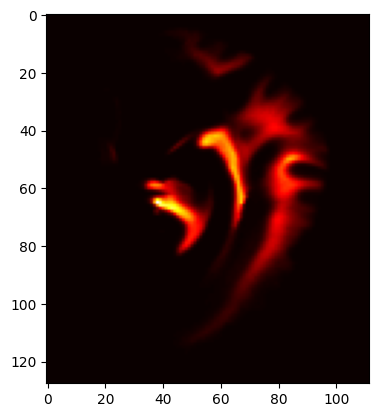

In [3]:
plt.imshow(raw_dataset[5][0][60], cmap='hot')

In [4]:
stats

{'bbox': {'z_min': 16,
  'z_max': 115,
  'y_min': 16,
  'y_max': 140,
  'x_min': 3,
  'x_max': 104},
 'padded_shape': (112, 128, 112),
 'norm_mean': 15.940274029018573,
 'norm_std': 65.34034382271614,
 'log1p_norm_mean': 0.7209655145793625,
 'log1p_norm_std': 1.4584000327893905}

In [5]:
_LATENT_DIMS = [2, 4, 6, 8, 12, 16, 32, 64, 128]

results = {}
for dim in _LATENT_DIMS:
    cfg = Config()
    cfg.latent_dim = dim
    cfg.normalisation = "zscore"
    cfg.use_lr_scheduler = True
    logger.info("--- %s ---", cfg.run_tag)
    per_subject = evaluate_model(cfg, raw_dataset, stats, device)
    if per_subject is not None:
        results[cfg.run_tag] = summarize(per_subject)

2026-07-01 22:33:01,870 INFO --- latent2_zscore_cosinelr ---
2026-07-01 22:33:22,039 INFO --- latent4_zscore_cosinelr ---
2026-07-01 22:33:42,173 INFO --- latent6_zscore_cosinelr ---
2026-07-01 22:34:02,192 INFO --- latent8_zscore_cosinelr ---


KeyboardInterrupt: 

In [6]:
out = out_dir / "dimarison_latent_dims.json"
out.write_text(json.dumps(results, indent=2))
logger.info("Saved -> %s", out)

2026-07-01 16:00:57,937 INFO Saved -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/jsons/dimarison_latent_dims.json


In [6]:
out = out_dir / "comparison_latent_dims.json"
results = json.loads(out.read_text())

In [7]:
_print_table(results)


Run                                      R² ± std_err       MAE  Pearson r     SSIM
------------------------------------------------------------------------------------
latent128_zscore_cosinelr            0.9490 ± 0.0081    1.2578     0.9743   0.9892
latent64_zscore_cosinelr             0.9384 ± 0.0102    1.3476     0.9675   0.9873
latent32_zscore_cosinelr             0.9217 ± 0.0119    1.6183     0.9565   0.9812
latent16_zscore_cosinelr             0.8984 ± 0.0137    1.9850     0.9404   0.9763
latent12_zscore_cosinelr             0.8886 ± 0.0142    1.9091     0.9361   0.9769
latent8_zscore_cosinelr              0.8676 ± 0.0149    2.0741     0.9224   0.9738
latent6_zscore_cosinelr              0.8514 ± 0.0172    2.1682     0.9129   0.9714
latent4_zscore_cosinelr              0.8371 ± 0.0172    2.5045     0.9010   0.9643
latent2_zscore_cosinelr              0.6949 ± 0.0299    3.3648     0.8297   0.9441


In [8]:
r2_results = [metric['r2'] for tag, metric in results.items()]
r2_results

[{'mean': 0.6948915928002172, 'std_err': 0.029904107006653666},
 {'mean': 0.8371156070056378, 'std_err': 0.017219542855952674},
 {'mean': 0.8514275506838856, 'std_err': 0.017157913597807717},
 {'mean': 0.8675606046747041, 'std_err': 0.014941135632452444},
 {'mean': 0.8886286288299816, 'std_err': 0.014223466442799738},
 {'mean': 0.8983545555364365, 'std_err': 0.013725178110130104},
 {'mean': 0.9217428449016289, 'std_err': 0.011921866190992381},
 {'mean': 0.9384310201510487, 'std_err': 0.010245820478516555},
 {'mean': 0.9490469350110764, 'std_err': 0.008114472691544}]

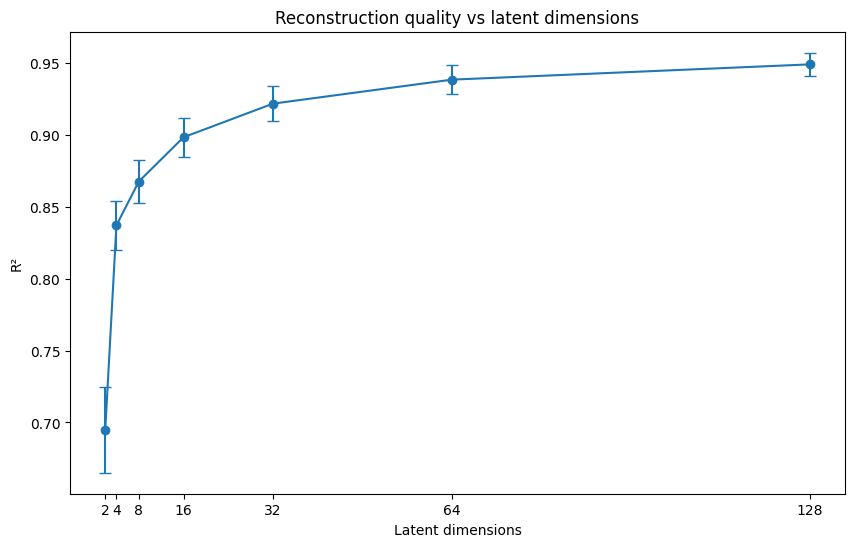

In [9]:
_LATENT_DIMS = [2, 4, 8, 16, 32, 64, 128]
means    = [results[tag]['r2']['mean'] for tag in results if tag not in ['latent6_zscore_cosinelr', 'latent12_zscore_cosinelr']]
std_errs = [results[tag]['r2']['std_err'] for tag in results if tag not in ['latent6_zscore_cosinelr', 'latent12_zscore_cosinelr']]

plt.figure(figsize=(10,6))
plt.errorbar(np.array(_LATENT_DIMS), means, yerr=std_errs, marker='o', capsize=4)
# plt.xscale('log')
plt.xlabel("Latent dimensions")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
plt.xticks(_LATENT_DIMS)
plt.ylabel("R²")
plt.title("Reconstruction quality vs latent dimensions")
plt.show()

In [10]:
# plot reconstructions of different brain slices 

# Cox models for all dims 
- plot of concordance index vs dimension (note: clinical + latent lines on this plot?)
    - **maybe that should be on after running the below tests where I choose the best hidden dims and then rank them and then check what the best amount for test c-index is?**
- emmm but cox on all latent codes or just one? or sth like the plot Joan had - cox when adding next PCAs?
- **so for each latent dim: fitting univariate cox for all latent codes and ordering them by most useful and then plotting concordance index when adding them vs naive(clinical)**
- **and doing that on both training and testing**
- how does the univariate vs multivariate cox work - running multivariate can show which components are the most significant and then univariate is just a model using the selected ones - so it might be better because it has less covariates? 
- ahhhh is it that if the pcs are ranked the concordance index is higher as compared to when unranked? it's the plot from the first OHBM results notebook? with many many lines - **this justifies running univariate for all dims and then ordering them** by c-index - or hazard? or p-value? **and then running cox by adding consecutive dims on train and test set to check the c-index and the best amount of added latent dims**
- or I'd have to change if the same holds for these latent dims bcst hey're not PCs?
- AH - and plotting training and test because the c-index on training increases with added components? and then the test verifies that; so with more added components the c-index decreases?
- or of cox on just the statistically significant dims? - would that be just another approach?
- and then possbily that we'll stick to the 4 dims one? 
- how do I interpret the concordance index and the p-value? so that I make the choice of the cox model based on that?

## Encode or load codes

In [10]:
from cox import (_get_or_encode, _build_df)
from utils import unpad_ucsf_ids

In [11]:
train_val_ids = splits["train"] + splits["val"]
test_ids      = splits["test"]
all_ids       = train_val_ids + test_ids

# unpadded set for df filtering after merge
train_val_set = {unpad_ucsf_ids(s) if "UCSF" in s else s for s in train_val_ids}


In [ ]:
with open(Path(base_cfg.jsons_dir) / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

clinical = pd.read_csv(base_cfg.clinical_csv)
out_dir = Path(base_cfg.jsons_dir)
# summaries_dir = out_dir / "cox_summaries"
# summaries_dir.mkdir(parents=True, exist_ok=True)

results = {}
for dim in _LATENT_DIMS:
    run_cfg = Config()
    run_cfg.latent_dim       = dim
    run_cfg.normalisation    = "zscore"
    run_cfg.use_lr_scheduler = True

    logger.info("=== latent_dim=%d ===", dim)
    codes, ids = _get_or_encode(run_cfg, all_ids, id_to_cohort, stats, device)

2026-06-29 17:05:50,547 INFO === latent_dim=2 ===
2026-06-29 17:05:59,665 INFO Encoded (1001, 2) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent2_zscore_cosinelr
2026-06-29 17:05:59,665 INFO === latent_dim=4 ===
2026-06-29 17:06:08,359 INFO Encoded (1001, 4) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent4_zscore_cosinelr
2026-06-29 17:06:08,360 INFO === latent_dim=8 ===
2026-06-29 17:06:17,060 INFO Encoded (1001, 8) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent8_zscore_cosinelr
2026-06-29 17:06:17,061 INFO === latent_dim=16 ===
2026-06-29 17:06:25,949 INFO Encoded (1001, 16) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent16_zscore_cosinelr
2026-06-29 17:06:25,950 INFO === latent_dim=32 ===
2026-06-29 17:06:34,560 INFO Encoded (1001, 32) -> /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent32_zscore_cosinelr
2026-06-2

In [12]:
DIM = 2
with open(Path(base_cfg.jsons_dir) / "id_to_cohort.json") as f:
    id_to_cohort = json.load(f)

clinical = pd.read_csv(base_cfg.clinical_csv)
out_dir = Path(base_cfg.jsons_dir)

run_cfg = Config()
run_cfg.latent_dim       = DIM
run_cfg.normalisation    = "zscore"
run_cfg.use_lr_scheduler = True
codes, ids = _get_or_encode(run_cfg, all_ids, id_to_cohort, stats, device)
df, z_cols = _build_df(codes, ids, clinical, DIM)

2026-07-01 22:35:29,480 INFO Loading cached codes from /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent2_zscore_cosinelr


In [13]:
df

,z1,z2,id,ID,age,sex,eor,mgmt,kps (preop),OS (days),...,Core lesion TDMap,Non-enhancing TDMap,Non-enhancing lesion TDMap,Enhancing TDMap,Enhancing lesion TDMap,Core+Enhancing TDMap,Core+Enhancing lesion TDMap,cohort,site,OS (days) - corrected
0,7.442652,-1.814658,UPENN-GBM-00147_11,UPENN-GBM-00147_11,82.41,1,1.0,0.0,NaN,80.000000,...,0.804185,130.299588,2.866155,74.560762,1.046598,100.428056,1.047600,1,1,107.143828
1,8.395545,0.737671,UCSF-PDGM-430,UCSF-PDGM-430,79.00,0,2.0,0.0,NaN,406.000000,...,0.214835,255.461534,2.799048,133.118295,0.736955,123.039131,0.736956,0,0,406.000000
2,2.934149,8.821489,UCSF-PDGM-472,UCSF-PDGM-472,76.00,1,0.0,2.0,NaN,38.000000,...,1.278647,124.437120,4.896154,117.381894,2.580636,123.730019,2.580733,0,0,38.000000
3,7.562628,-3.167649,UCSF-PDGM-332,UCSF-PDGM-332,68.00,0,2.0,2.0,NaN,42.000000,...,0.736385,175.369296,5.865094,146.804520,1.725475,148.421375,1.725487,0,0,42.000000
4,2.055551,-1.788871,UPENN-GBM-00337_11,UPENN-GBM-00337_11,62.34,0,2.0,NaN,NaN,385.000000,...,2.775009,112.819121,4.693732,157.227826,3.901126,166.981916,3.917241,1,1,515.629674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,-0.616800,2.428060,TCGA-02-0009,TCGA-02-0009,61.00,1,NaN,0.0,80.0,321.786366,...,0.379249,70.014250,1.257232,148.231487,0.614384,88.865209,0.650983,2,1,430.967790
995,8.370879,-0.872665,TCGA-06-0238,TCGA-06-0238,46.00,0,NaN,NaN,80.0,404.731299,...,0.466644,99.463595,3.751923,56.781503,0.673405,54.285974,0.678839,2,1,542.055761
996,3.910202,5.659836,TCGA-76-6664,TCGA-76-6664,49.00,1,NaN,2.0,80.0,236.842760,...,0.462849,93.481570,3.777519,46.345565,0.955934,45.520411,1.009172,2,1,317.203001
997,7.181006,-4.663607,TCGA-06-0241,TCGA-06-0241,65.00,1,NaN,NaN,100.0,454.698126,...,0.780565,171.162536,1.740584,97.543244,1.220562,107.294998,1.223833,2,1,608.976225


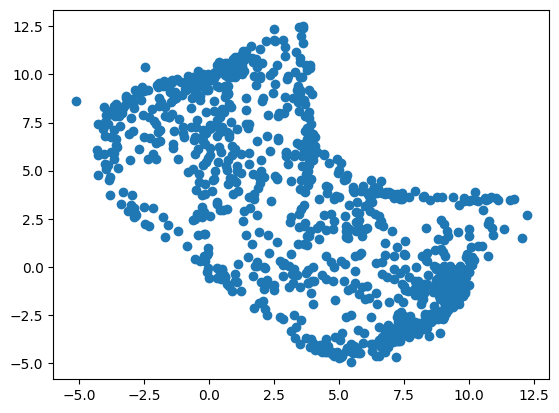

In [16]:
plt.scatter(df['z1'], df['z2'])

## Train and test split prep - Add cross validation here? so all the metrics are done for a k-fold cross-val splits? 

In [ ]:
# split the whole cohort into test and train
# do I have to also account for the censoring or not? how?
from sklearn.model_selection import train_test_split

# Combined stratification key: e.g. "ucsf_censored", "upenn_uncensored", etc.
df["strat_key"] = df["cohort"].astype(str) + "_" + df["status"].astype(str)

print("Stratification group sizes:")
print(df["strat_key"].value_counts().sort_index())

train_idx, test_idx = train_test_split(
    df.index, # RangeIndex object
    test_size=0.2,
    # random_state=499,
    shuffle=True,
    stratify=df["strat_key"]
)

df_train = df.loc[train_idx]
df_test  = df.loc[test_idx]

# Verify
for split_name, split_df in [("Train", df_train), ("Test", df_test)]:
    print(f"\n{split_name} (N={len(split_df)}):")
    print("  Cohort proportions:\n", split_df["cohort"].value_counts(normalize=True).round(3))
    print("  Censoring rate:    ", (split_df["status"] == 0).mean().round(3))

Stratification group sizes:
strat_key
0_0.0    144
0_1.0    223
1_0.0     14
1_1.0    482
2_0.0     21
2_1.0     82
3_0.0      9
3_1.0     24
Name: count, dtype: int64

Train (N=799):
  Cohort proportions:
 cohort
1    0.497
0    0.367
2    0.104
3    0.033
Name: proportion, dtype: float64
  Censoring rate:     0.188

Test (N=200):
  Cohort proportions:
 cohort
1    0.495
0    0.370
2    0.100
3    0.035
Name: proportion, dtype: float64
  Censoring rate:     0.19


## For 4-dim latent codes

In [214]:
# run univariate on each dim and plot importance of each element z1, z2...
# order by best and plot c-index by adding consecutive "best" components on train and test 
# also plot clinical only c-index - so a line? bcs this would be the baseline

# and then do that for all dimensions? 
# see what the best c-index is - and choose that model as the final one?

In [215]:
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


DURATION_COL     = "OS (days) - corrected"
EVENT_COL        = "status"
CLINICAL_COLS    = ["age", "sex"]

Cindices_training, HRs_uni, HRs_uni_pval = {}, {}, {}
Cindices_testing = {}

for dim in range(DIM):
    cph_uni = CoxPHFitter(
        penalizer=0.1,
        l1_ratio=0.01,
        baseline_estimation_method="breslow" 
    )
    
    try:
        # Train Cox
        cph_uni.fit(
            df_train[[f"z{dim+1}"] + [DURATION_COL, EVENT_COL, "age", "sex"]], 
            DURATION_COL, 
            EVENT_COL,
            show_progress=False
        )
        Cindices_training[dim] = cph_uni.concordance_index_
        HRs_uni[dim] = [cph_uni.hazard_ratios_.values[0], np.exp(cph_uni.confidence_intervals_.values[0][0]), np.exp(cph_uni.confidence_intervals_.values[0][1])]
        HRs_uni_pval[dim] = cph_uni.summary['p'].values[0]
        
        # Test Cox
        df_tst = df_test[[f"z{dim+1}"] + [DURATION_COL, EVENT_COL, "age", "sex"]]
        Cindices_testing[dim] = concordance_index(
            df_tst[DURATION_COL], 
            -cph_uni.predict_partial_hazard(df_tst), 
            df_tst[EVENT_COL]
        )
    except Exception as e:
        print(f"Skipped {dim} due to error: {e}")
        Cindices_training[dim] = 0.0 # Failed components receive zero power
        Cindices_testing[dim] = 0.0 # Failed components receive zero power

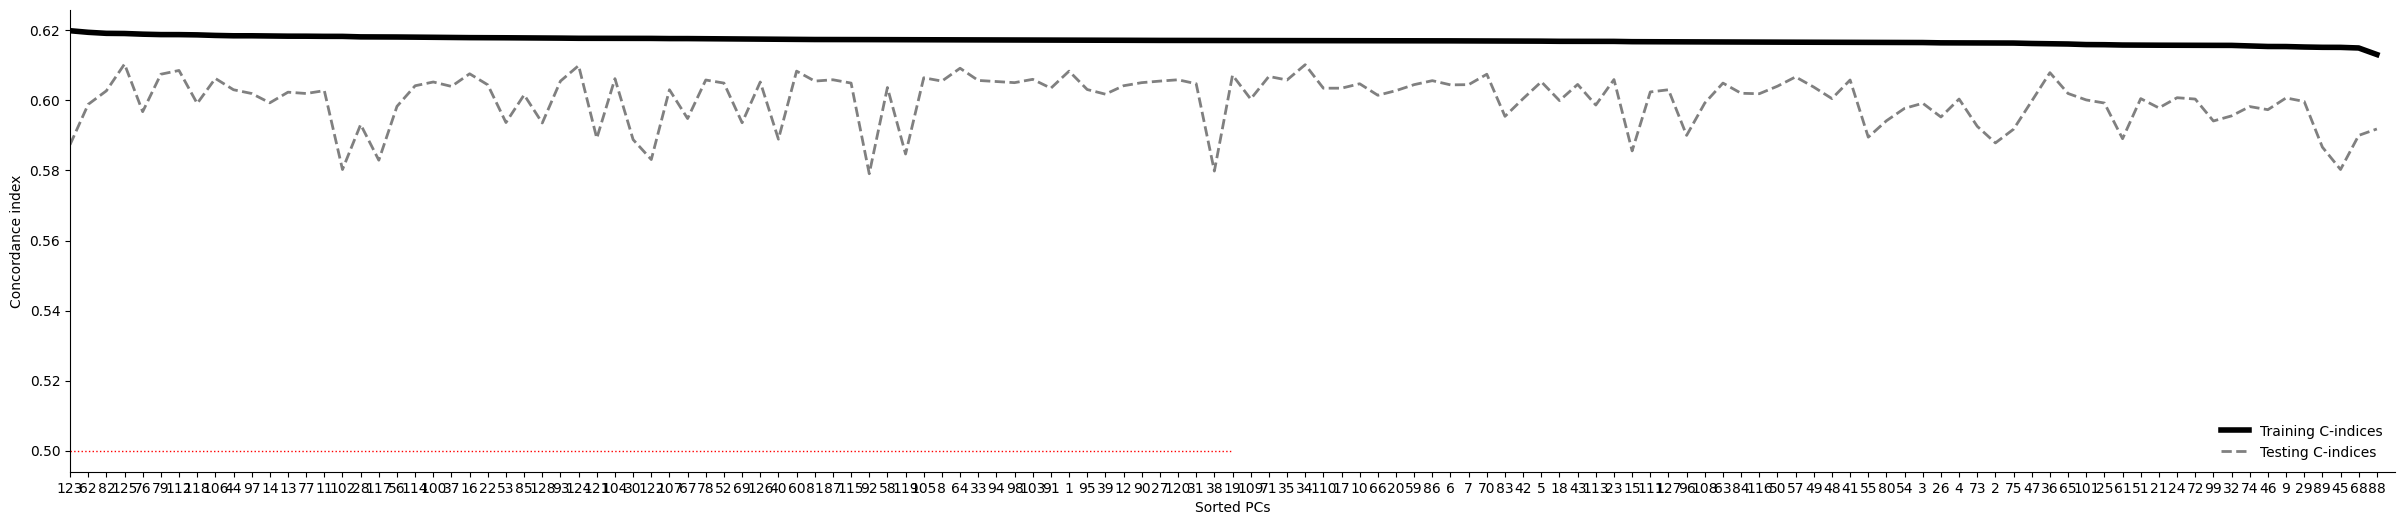

In [ ]:
# Sort from strongest to weakest
mode = "training"
components_sorted_by_power = sorted(
    Cindices_training if mode=="training" else Cindices_testing, 
    key=Cindices_training.get if mode=="training" else Cindices_testing.get, 
    reverse=True
)
# os.makedirs(f"{save_dir}/sorting-{mode}", exist_ok=True)

sorted_Cindices_training = np.array([Cindices_training[ii] for ii in components_sorted_by_power])
sorted_Cindices_testing = np.array([Cindices_testing[ii] for ii in components_sorted_by_power])

fig, ax = plt.subplots(1, 1, figsize=(30,6))

ax.plot(sorted_Cindices_training, label="Training C-indices", linewidth=4, linestyle="solid", color="black")
ax.plot(sorted_Cindices_testing, label="Testing C-indices", linewidth=2, linestyle="dashed", color="gray")
ax.plot([0, DIM], [0.5, 0.5], linewidth=1, linestyle="dotted", color="red")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(0,DIM))
ax.set_xticklabels(np.array(components_sorted_by_power)+1)
ax.set_xlim([0,DIM])
ax.set_xlabel("Sorted PCs")
ax.set_ylabel("Concordance index")

ax.legend(frameon=False)

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/C-indices_sorted-{mode}.{fmt}", dpi=200, format=fmt)

Text(0, 0.5, 'Hazard ratio ($\\exp [\\beta]$)')

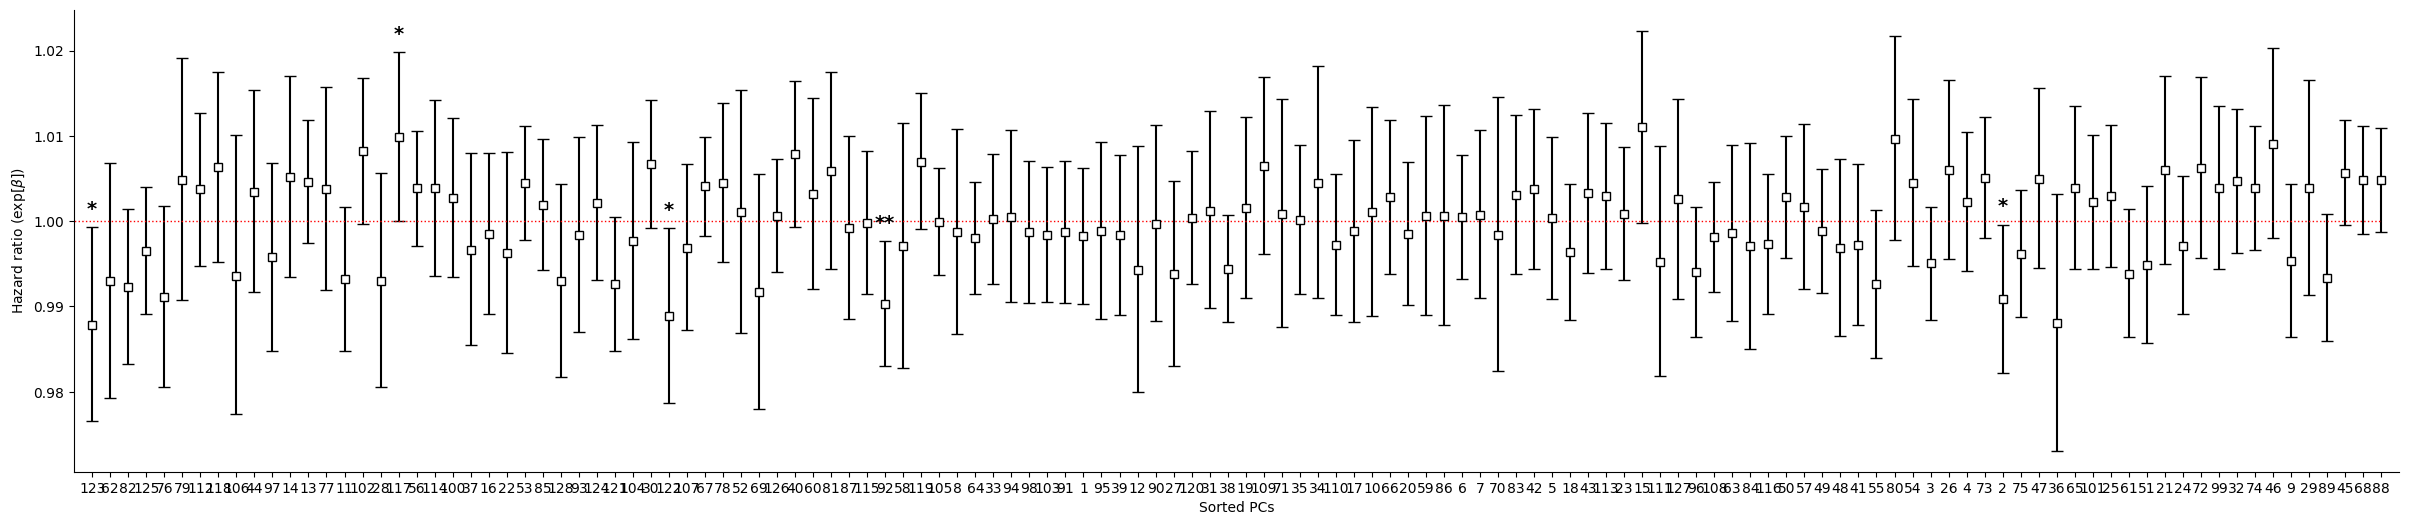

In [217]:
sorted_HRs_uni = np.array([HRs_uni[ii] for ii in components_sorted_by_power])

fig, ax = plt.subplots(1, 1, figsize=(30,6))

ax.errorbar(
    x=range(1,DIM+1), 
    y=sorted_HRs_uni[:,0], 
    yerr=np.array([sorted_HRs_uni[:,0]-sorted_HRs_uni[:,1],sorted_HRs_uni[:,2]-sorted_HRs_uni[:,0]]),
    fmt='s',
    markeredgecolor='black',
    markerfacecolor='white',
    capsize=4,
    ecolor='black'
)
for x, comp in enumerate(components_sorted_by_power):

    p = HRs_uni_pval[comp]

    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        continue

    # place stars slightly above the upper CI
    y = sorted_HRs_uni[x, 2]

    ax.text(
        x+1,
        y + 0.02 * (sorted_HRs_uni[:,2].max() - sorted_HRs_uni[:,1].min()),
        stars,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )
ax.plot([-1, DIM], [1, 1], linewidth=1, linestyle="dotted", color="red")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(1,DIM+1))
ax.set_xticklabels(np.array(components_sorted_by_power)+1)
ax.set_xlim([0,DIM+1])
ax.set_xlabel("Sorted PCs")
ax.set_ylabel("Hazard ratio ("+r'$\exp [\beta]$'+")")

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/Hazard-ratios_sorted-{mode}.{fmt}", dpi=200, format=fmt)

In [218]:
from tqdm import tqdm
Cindices_training_CoxSorted = {}
Cindices_testing_CoxSorted = {}
logHRs_CoxSorted = {}

for k in tqdm(range(1,DIM+1), desc="Fitting Cox models with incremental components"):
    
    # Take the top k most important components
    included_components = components_sorted_by_power[:k]

    cph_multi = CoxPHFitter(
        penalizer=0.1,
        l1_ratio=0.01,
        baseline_estimation_method="breslow" 
    )
    
    try:
        # Train Cox
        cph_multi.fit(
            df_train[[f"z{dim+1}" for dim in included_components]+ [DURATION_COL, EVENT_COL, "age", "sex"]], 
            DURATION_COL,
            EVENT_COL,
            show_progress=False
        )
        Cindices_training_CoxSorted[k] = cph_multi.concordance_index_
        logHRs_CoxSorted[k] = cph_multi.params_.values

        # Test Cox
        df_tst = df_test[[f"z{dim+1}" for dim in included_components]+ [DURATION_COL, EVENT_COL, "age", "sex"]]
        Cindices_testing_CoxSorted[k] = concordance_index(
            df_tst[DURATION_COL], 
            -cph_multi.predict_partial_hazard(df_tst), 
            df_tst[EVENT_COL]
        )

    except Exception as e:
        print(f"Fitting error for k={k} components: {e}")
        continue

## Naaive model including only clinical data
cph_naive = CoxPHFitter(
        penalizer=0,
        l1_ratio=0,
        baseline_estimation_method="breslow" 
    )
cph_naive.fit(
    df_train[[DURATION_COL, EVENT_COL, "age", "sex"]], 
    DURATION_COL, 
    EVENT_COL,
    show_progress=False
)
Cindex_training_naive = cph_naive.concordance_index_
df_tst = df_test[[DURATION_COL, EVENT_COL, "age", "sex"]]
Cindex_testing_naive = concordance_index(
    df_tst[DURATION_COL], 
    -cph_naive.predict_partial_hazard(df_tst), 
    df_tst[EVENT_COL]
)

Fitting Cox models with incremental components: 100%|██████████| 128/128 [01:47<00:00,  1.19it/s]


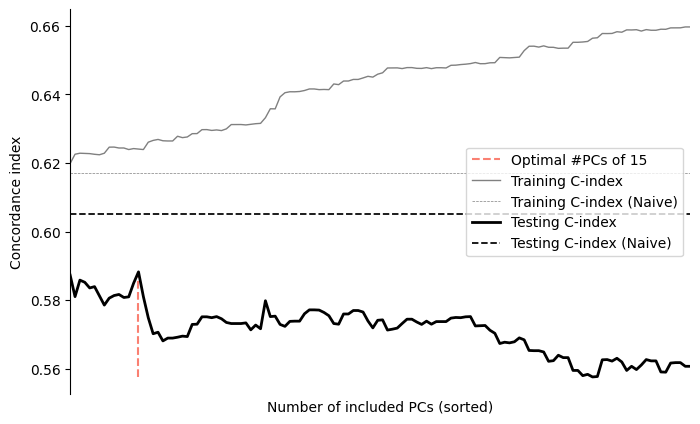

In [219]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

to_include_PCs = np.array(list(Cindices_testing_CoxSorted.values())).argmax()
to_included_PCs_Cindex = np.array(list(Cindices_testing_CoxSorted.values())).max()
ax.plot(
    [to_include_PCs, to_include_PCs], 
    [np.array(list(Cindices_testing_CoxSorted.values())).min(), to_included_PCs_Cindex],
    linestyle="dashed",
    color="salmon",
    label=f"Optimal #PCs of {1+to_include_PCs}"
)

ax.plot(Cindices_training_CoxSorted.values(), linestyle='solid', linewidth=1, color="gray", label="Training C-index")
ax.plot([0, DIM-1], [Cindex_training_naive, Cindex_training_naive], linestyle='dashed', linewidth=.5, color="gray", label="Training C-index (Naive)")

ax.plot(Cindices_testing_CoxSorted.values(), linestyle='solid', linewidth=2, color="black", label="Testing C-index")
ax.plot([0, DIM-1], [Cindex_testing_naive, Cindex_testing_naive], linestyle='dashed', linewidth=1.25, color="black", label="Testing C-index (Naive)")

ax.spines[["top","right","bottom"]].set_visible(False)
ax.set_xticks([])
ax.set_ylabel("Concordance index")
ax.set_xlabel("Number of included PCs (sorted)")
ax.set_xlim([0,DIM-1])

ax.legend(frameon=True, loc="right")

# fig.tight_layout()
# fig.savefig(f"{save_dir}/sorting-{mode}/Final-Cox_C-index_sorted-{mode}.{fmt}", dpi=200, format=fmt)

# Cox models - clinical, latent, clinical + latent
- compute C-index on train AND on test
- log-likelihood
- from lifelines
- in Joan’s code

# Survival plots - low high risk

In [80]:
risk_score_training = np.dot(
    logHRs_CoxSorted[1+to_include_PCs][:-2], # Remove age and sex
    np.array([comps_training[:,k] for k in components_sorted_by_power[:1+to_include_PCs]])
)

risk_score_testing = np.dot(
    logHRs_CoxSorted[1+to_include_PCs][:-2], # Remove age and sex
    np.array([comps_testing[:,k] for k in components_sorted_by_power[:1+to_include_PCs]])
)

NameError: name 'comps_training' is not defined

In [ ]:
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival

for pc in [20,25,40,50]:
    assert pc <= 50, "pc must be < 50"
    threshold_low = np.percentile(risk_score_training, pc)
    threshold_high = np.percentile(risk_score_training, 100 - pc)
    assert threshold_low <= threshold_high, \
        f"Thresholds overlap: p{pc}={threshold_low:.3f} >= p{100-pc}={threshold_high:.3f}"

    months = range(0, 110, 10)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    colors = ["royalblue", "salmon"]
    labels = [f"Low risk", f"High risk"]

    for ax, risk_scores, hcpex_subset, title in zip(
        [ax1, ax2],
        [risk_score_training, risk_score_testing],
        [df_training, df_testing],
        ["Training set", "Testing set"]
    ):
        cohort_mask = np.where(risk_scores <= threshold_low, 0,
                    np.where(risk_scores >= threshold_high, 1, -1))

        OS_STATS = []
        GROUP_STATS = []
        nums = np.empty(shape=(2,), dtype=object)

        for i, group in enumerate([0, 1]):
            mask_cohort = cohort_mask == group
            diag = hcpex_subset[mask_cohort].copy()
            mask_valid = ~np.isnan(diag[event_col]) & ~np.isnan(diag[duration_col])
            diag = diag[mask_valid]

            nums[i] = []
            for t in months:
                nums[i].append((diag[duration_col] >= (t * daysXmonth)).sum())

            time, survival_prob, conf_int = kaplan_meier_estimator(
                diag[event_col] == 1, diag[duration_col], conf_type="log-log"
            )
            time = np.insert(time, 0, 0)
            survival_prob = np.insert(survival_prob, 0, 1)
            conf_int = np.insert(conf_int, 0, 1, axis=1)

            # Median survival line (survival = 0.5)
            if np.any(survival_prob <= 0.5):
                t_median = time[np.searchsorted(-survival_prob, -0.5)] / daysXmonth
                ax.hlines(0.5, 0, t_median, color="black", linewidth=0.8, linestyle="solid", alpha=0.25)
                ax.vlines(t_median, 0, 0.5, color="black", linewidth=0.8, linestyle="solid", alpha=0.25)

            # Plotting KMs
            ax.step(time / daysXmonth, survival_prob, where="post",
                    color=colors[i], label=labels[i])
            ax.fill_between(time / daysXmonth, conf_int[0], conf_int[1],
                            alpha=0.15, step="post", color=colors[i])
            for t in diag.loc[diag[event_col] == 0, duration_col].values:
                ax.plot(time[time == t] / daysXmonth, survival_prob[time == t],
                        "+", color=colors[i])

            OS_STATS.extend([
                (st, ovs) for st, ovs in zip(diag[event_col] == 1, diag[duration_col].values)
            ])
            GROUP_STATS.extend([i + 1 for _ in diag[duration_col].values])

        OS_STATS = np.array(OS_STATS, dtype=[('event', 'bool'), ('time', 'float')])
        chisquared, p_val, stats, covariance = compare_survival(OS_STATS, GROUP_STATS, return_stats=True)

        p_text = f"p = {round(p_val, 4)}"  if p_val>0.0001 else "p<0.0001"
        ax.text(0.70, 0.90,
                r"$\chi^2 =$" + f"{round(chisquared, 4)},\n{p_text}",
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round", alpha=0.1),
                color="red" if p_val <= 0.05 else "black")

        ax.set_title(f"{title}", fontweight="bold")
        ax.set_xlabel("Time (months)", fontsize=12)
        ax.set_ylabel("Overall survival", fontsize=12)
        if ax==ax1:
            ax.legend(loc="right")

        for ii, t in enumerate(months):
            ax.text(t-2, -0.07, f"{nums[0][ii]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[0])
            ax.text(t-2, -0.13, f"{nums[1][ii]}", transform=ax.transData, fontsize=11, verticalalignment='top', color=colors[1])
        ax.text(-2, -0.01, "No. at risk", transform=ax.transData, fontsize=11, verticalalignment='top', color="black", fontweight='bold')
        ax.hlines(0, -5, months[-1]+5, color="black", linewidth=.5)
        ax.set_ylim([-.200, 1.1])
        ax.set_xlim([-5, 75])
        ax.set_xticks(range(0, months[-1]+10, 10))
        ax.set_xticklabels(range(0, months[-1]+10, 10))
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.spines['left'].set_bounds(0, 1)
        ax.spines['bottom'].set_bounds(0, months[-1])
        ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    fig.savefig(f"{save_dir}/sorting-{mode}/Risk-scores_Kaplan-Meier_{pc}-{100-pc}_sorted-{mode}.{fmt}", dpi=200, format=fmt)

# Anatomical relevance?

# Results: clinical vs clinical+latent (CV, all dims)

Computed by `cox.py` (`python cox.py`) — stratified 5-fold CV (`StratifiedKFold` on
`cohort + "_" + status`), all subjects pooled (ignoring the AE's own train/val/test
split — the encoder is reconstruction-only, so this is fine for the Cox stage),
unpenalized `clinical` (age, sex) vs `clinical+latent` (age, sex, z1..zN) models,
same fold indices reused for both models within a given dim so every fold gives a
paired comparison.

Everything below **loads** the CSV/JSON saved by `cox.py` — nothing here refits a
model. Per-z screening (which individual z's are associated with survival) and any
"pick the best k components" step are deferred to a follow-up round.

In [11]:
cox_results_dir = Path(base_cfg.jsons_dir) / "cox_results"
model_comparison = json.loads((cox_results_dir / "model_comparison.json").read_text())

rows = []
for tag, models in model_comparison.items():
    dim = int(tag.replace("latent", ""))
    for model_name, stats_ in models.items():
        rows.append({"dim": dim, "model": model_name, **stats_})
comparison_df = pd.DataFrame(rows).sort_values(["model", "dim"])
comparison_df

,dim,model,train_c_mean,train_c_std,test_c_mean,test_c_std
0,2,clinical,0.614527,0.003690,0.610317,0.013447
2,4,clinical,0.614527,0.003690,0.610317,0.013447
4,6,clinical,0.614527,0.003690,0.610317,0.013447
6,8,clinical,0.614527,0.003690,0.610317,0.013447
8,12,clinical,0.614527,0.003690,0.610317,0.013447
10,16,clinical,0.614527,0.003690,0.610317,0.013447
12,32,clinical,0.614527,0.003690,0.610317,0.013447
14,64,clinical,0.614527,0.003690,0.610317,0.013447
16,128,clinical,0.614527,0.003690,0.610317,0.013447
1,2,clinical+latent,0.613671,0.004041,0.608022,0.009781


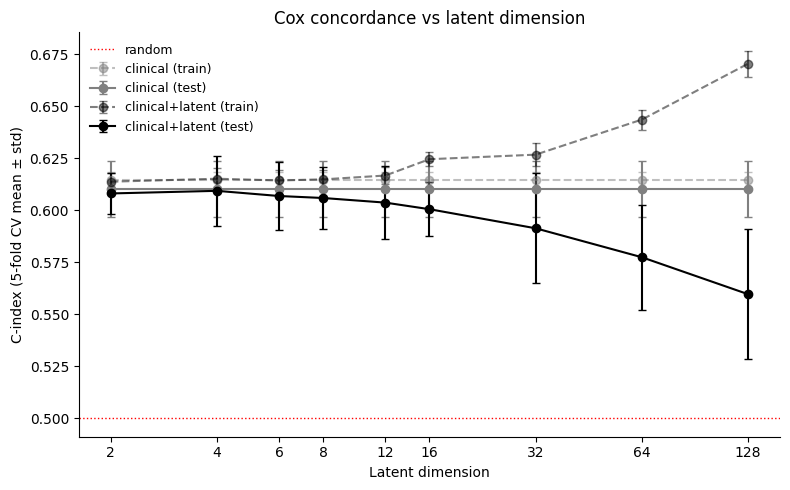

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"clinical": "gray", "clinical+latent": "black"}
for model_name, g in comparison_df.groupby("model"):
    g = g.sort_values("dim")
    ax.errorbar(g["dim"], g["train_c_mean"], yerr=g["train_c_std"],
                linestyle="dashed", marker="o", capsize=3,
                color=colors.get(model_name), alpha=0.5,
                label=f"{model_name} (train)")
    ax.errorbar(g["dim"], g["test_c_mean"], yerr=g["test_c_std"],
                linestyle="solid", marker="o", capsize=3,
                color=colors.get(model_name),
                label=f"{model_name} (test)")
ax.axhline(0.5, color="red", linestyle="dotted", linewidth=1, label="random")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(comparison_df["dim"].unique()))
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("Latent dimension")
ax.set_ylabel("C-index (5-fold CV mean ± std)")
ax.set_title("Cox concordance vs latent dimension")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## Per-covariate stability for a chosen dim

`frac_folds_p_lt_05` = fraction of the 5 CV folds where that covariate's train-fit
p-value was < 0.05 (not an average of p-values — those can't be combined validly,
see the plan discussion). `mean_hr` is the mean hazard ratio across folds.

In [27]:
DIM = 12  # pick a dim to inspect
covariate_summary = pd.read_csv(cox_results_dir / f"latent{DIM}_covariate_summary.csv")

print("clinical covariates:")
display(covariate_summary[covariate_summary["model"] == "clinical"])

print("\ntop 15 clinical+latent covariates by frac_folds_p_lt_05:")
top_covariates = (
    covariate_summary[covariate_summary["model"] == "clinical+latent"]
    .sort_values("frac_folds_p_lt_05", ascending=False)
    .head(15)
)
display(top_covariates)

clinical covariates:


,model,covariate,mean_hr,median_hr,mean_p,n_folds_converged,frac_folds_p_lt_05
0,clinical,age,1.026739,1.026301,4.388963e-12,5,1.0
1,clinical,sex,0.937468,0.935362,4.801409e-01,5,0.0



top 15 clinical+latent covariates by frac_folds_p_lt_05:


,model,covariate,mean_hr,median_hr,mean_p,n_folds_converged,frac_folds_p_lt_05
2,clinical+latent,age,1.026757,1.027077,1.201501e-11,5,1.0
14,clinical+latent,z11,0.991356,0.993478,2.956318e-01,5,0.2
4,clinical+latent,z1,0.994659,0.993900,3.686412e-01,5,0.0
5,clinical+latent,z2,1.000367,1.002929,5.255430e-01,5,0.0
6,clinical+latent,z3,0.996101,0.995855,6.329538e-01,5,0.0
3,clinical+latent,sex,0.942955,0.953751,5.218409e-01,5,0.0
7,clinical+latent,z4,1.000825,0.999616,8.074904e-01,5,0.0
8,clinical+latent,z5,0.992010,0.992639,3.095888e-01,5,0.0
10,clinical+latent,z7,0.999738,0.999879,8.809036e-01,5,0.0
9,clinical+latent,z6,0.996246,0.994846,5.515733e-01,5,0.0


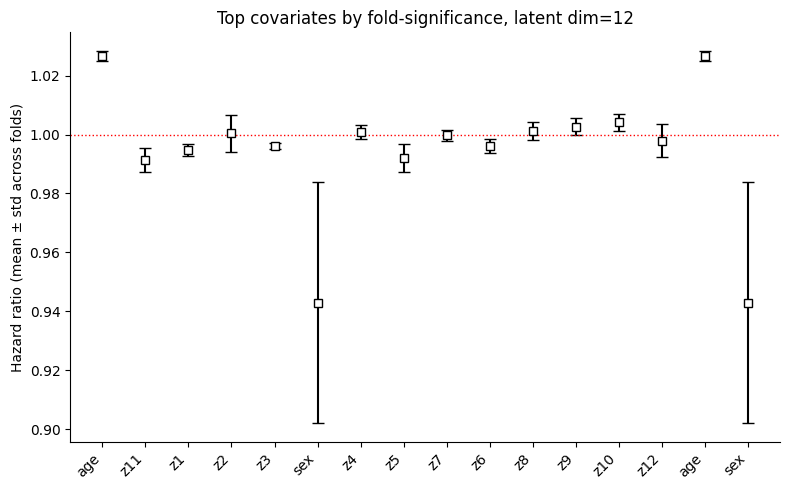

In [28]:
covariate_folds = pd.read_csv(cox_results_dir / f"latent{DIM}_covariate_folds.csv")
plot_covariates = list(top_covariates["covariate"]) + ["age", "sex"]

plot_df = (
    covariate_folds[covariate_folds["covariate"].isin(plot_covariates)
                     & (covariate_folds["model"] == "clinical+latent")]
    .groupby("covariate")["hr"].agg(["mean", "std"])
    .reindex(plot_covariates)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(range(len(plot_df)), plot_df["mean"], yerr=plot_df["std"],
            fmt="s", markeredgecolor="black", markerfacecolor="white",
            capsize=4, ecolor="black")
ax.axhline(1.0, color="red", linestyle="dotted", linewidth=1)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
ax.set_ylabel("Hazard ratio (mean ± std across folds)")
ax.set_title(f"Top covariates by fold-significance, latent dim={DIM}")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Follow-up: clinical vs clinical+z3 (dim=4)

`z3` stood out in the dim=4 `clinical+latent` fit. Testing it on its own here is a
new hypothesis generated by looking at that fit — worth treating this result as a
first check rather than a fully independent confirmation, though the risk is small
since this only compares 2 candidates (not a search over many). Reuses
`cox.py`'s `_fit_fold_model`/`_strat_key` directly (same CV logic as the main
comparison), just with a one-off covariate set instead of all z's of a dim.

In [35]:
from cox import _get_or_encode, _build_df, _fit_fold_model, _strat_key, N_SPLITS, CLINICAL_COLS
from sklearn.model_selection import StratifiedKFold

DIM = 4
run_cfg = Config()
run_cfg.latent_dim       = DIM
run_cfg.normalisation    = "zscore"
run_cfg.use_lr_scheduler = True
codes4, ids4 = _get_or_encode(run_cfg, all_ids, id_to_cohort, stats, device)
df4, z_cols4 = _build_df(codes4, ids4, clinical, DIM)
print("n =", len(df4))

models_z3 = {"clinical": CLINICAL_COLS, "clinical+z3": CLINICAL_COLS + ["z3"]}
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=Config.random_seed)
strat_key4 = _strat_key(df4)

model_rows, covariate_rows = [], []
for fold_id, (train_idx, test_idx) in enumerate(skf.split(df4, strat_key4)):
    df_train, df_test = df4.iloc[train_idx], df4.iloc[test_idx]
    for name, covariates in models_z3.items():
        result = _fit_fold_model(df_train, df_test, covariates)
        model_rows.append({"fold": fold_id, "model": name,
                            "train_c": result["train_c"], "test_c": result["test_c"]})
        for covariate, row in result["covariates"].iterrows():
            covariate_rows.append({"fold": fold_id, "model": name, "covariate": covariate,
                                    "hr": row["hr"], "p": row["p"]})

model_folds_z3 = pd.DataFrame(model_rows)
covariate_folds_z3 = pd.DataFrame(covariate_rows)

print("\nC-index (mean ± std across folds):")
display(model_folds_z3.groupby("model")[["train_c", "test_c"]].agg(["mean", "std"]))

z3_rows = covariate_folds_z3[covariate_folds_z3["covariate"] == "z3"]
print(f"\nz3 significant (p<0.05) in {(z3_rows['p'] < 0.05).sum()}/{N_SPLITS} folds")
display(z3_rows)

2026-07-01 16:21:14,105 INFO Loading cached codes from /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/latents/latent4_zscore_cosinelr


n = 999

C-index (mean ± std across folds):


train_c              test_c          
                 mean       std      mean       std
model                                              
clinical     0.614527  0.003690  0.610317  0.013447
clinical+z3  0.615430  0.004757  0.611361  0.017974


z3 significant (p<0.05) in 1/5 folds


,fold,model,covariate,hr,p
4,0,clinical+z3,z3,0.996389,0.189621
9,1,clinical+z3,z3,0.995190,0.088070
14,2,clinical+z3,z3,0.994317,0.040744
19,3,clinical+z3,z3,0.994346,0.051590
24,4,clinical+z3,z3,0.994821,0.066047
